# Process Annotated Data
Translate Label Studio JSON files to a format for ML

In [15]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd

# Relative imports
import sys, os

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

from utils.utils import analyze_category_distribution_from_dict, plot_cooccurrence_heatmap

In [16]:
ANNOTATED_DATA_JSON_PATH = "../data/input/annotated-gold-standard.json"
TAXONOMY_PATH = "../data/output/taxonomy_autogen_v2.csv"

FULL_DATA_OUTPUT_PATH = "../data/output/full_dataset.json"
TAXONOMY_V3_PATH = "../data/output/taxonomy_autogen_v3.csv"

RANDOM_STATE = 42

## Import from JSON file

In [17]:
with open(ANNOTATED_DATA_JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

2000

In [18]:
taxonomy = pd.read_csv(TAXONOMY_PATH)
taxonomy.head(5)

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"['Care leaver', 'Care experienced (under 25)']",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


In [19]:
ENTITY_LABELS = {'Person_Name', 'Person_Role', 'Person_Pronoun'}
CAT_LABELS = set(taxonomy.cat_label.values.tolist())

records = []

for task in data:
    id = task['data']['id']
    text = task['data']['note_content']
    
    task_annotations = task['annotations']
    if len(task_annotations) == 0:
        continue
    elif len(task_annotations) > 1:
        annotation = min(task_annotations, key=lambda x: datetime.strptime(x['created_at'], "%Y-%m-%dT%H:%M:%S.%fZ"))
    else:
        annotation = task_annotations[0]
    
    needs = []
    entities = []
    relations = []
    seen_entities = set()

    for ann in annotation['result']:
        if ann['type'] == 'relation':
            relations.append({"from": ann['from_id'], "to": ann['to_id']})

        elif ann['type'] == 'labels':
            label = ann['value']['labels'][0]
            item = {
                "id": ann['id'],
                "start": ann['value']['start'],
                "end": ann['value']['end'],
                "label": label
            }

            if ann['from_name'] == 'need_labels' and label in CAT_LABELS:
                needs.append(item)
            elif ann['from_name'] == 'entity_labels' and label in ENTITY_LABELS:
                key = (ann['id'], label)
                if key not in seen_entities:
                    seen_entities.add(key)
                    entities.append(item)
            else:
                print(f"Skipping: {ann['from_name']}, {label} in {id}")

    records.append({"id": id, "text": text, "needs": needs, "entities": entities, "relations": relations})

In [20]:
records[5]

{'id': 'e2401f2c-fa87-6abd-0ce2-6053c459ead3',
 'text': "[Category: Tenancy Management] Re: Ryan Munoz DIR0146633\n\nEmilia-Alesia Marino <<EMAIL_ADDRESS>>\n<DATE_TIME>)\nto Yemi, Frances, Abigail Shaffer\n\nHi Gina Moore, \n\nAs discussed client is downstairs in Hackney Service Centre and Customer Services will be scanning Ms Lewis's Hospital Discharge papers.  Ms Lewis's Social Worker - Monique Tulloch will also be emailing you. \n\nThank you\n\n\nConnie Lawrence\nHostel Manager\nTemporary Accommodation\nBenefits and Housing Needs\nCustomer Services \n1 Hillman Street\n<LOCATION>\n<UK_POSTCODE>\n\ntelephone: <DATE_TIME>; <EMAIL_ADDRESS> \n\n\nOn Tue, <DATE_TIME> at 14:59, Gabrielle Davis <<EMAIL_ADDRESS>> wrote:\nHello Emilia, \n\nI can cancel the dod if client provide letter from hospital confirming that she was admitted at the hospital.\n\n\nRegards, \n\n\nOn Tue, <DATE_TIME> at 13:03, <LOCATION> <<EMAIL_ADDRESS>> wrote:\nHi Gina Moore, \n\nI've just received a call from the above 

## Count Duplicates (on note text)

In [21]:
df = pd.DataFrame(records)
df.duplicated(subset=['text']).value_counts()

False    1908
True       92
Name: count, dtype: int64

In [22]:
# Count lead time
lead_times = [x['annotations'][0]['lead_time'] for x in data if len(x["annotations"]) > 0]
sum([t for t in lead_times if t is not None])/(60*60)

24.431676666666664

## Create Binary Label Matrix

## Analyse distribution

,label,frequency,IRLbl
0,health_medical_condition,317,1.000000
1,property_level_disrepair_damp_mould,285,1.112281
2,safety_risk_antisocial_behaviour,271,1.169742
3,care_social_care_involvement,222,1.427928
4,health_mental_health,172,1.843023
5,health_care_setting,165,1.921212
6,mobility_mobility_physical,156,2.032051
7,life_events_temporary,146,2.171233
8,disability_requires_adapted_property,135,2.348148
9,life_events_life_events,126,2.515873


,Metric,Value
0,MeanIR,6.52
1,MaxIR,52.83
2,CVIR,1.32


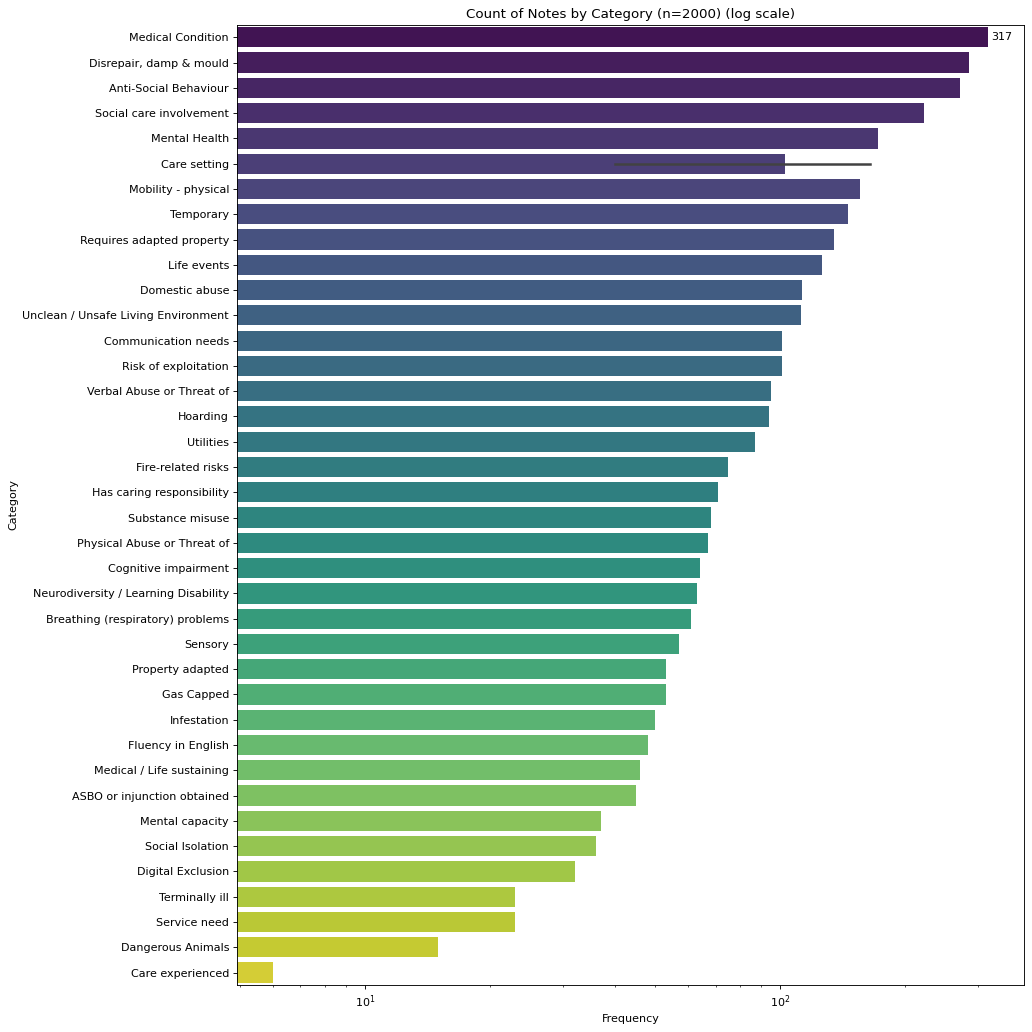

In [23]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records, taxonomy)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

## Drop Low Prevalence Categories

In [24]:
taxonomy_v3 = taxonomy.copy()

dropped_categories = [
    'care_care_experienced', # 6 hits
    'cautions_dangerous_animals', # 15 hits
    'mobility_service_need', # 23 hits
    'health_terminally_ill', # 23 hits
]

mask = taxonomy['cat_label'].isin(dropped_categories)
taxonomy_v3 = taxonomy[~mask].reset_index(drop=True)
taxonomy_v3.to_csv(TAXONOMY_V3_PATH, index=False)

taxonomy_v3.head()

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
1,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
2,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
3,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...
4,Cautions,Physical Abuse or Threat of,"['Physical Abuse (actual)', 'Physical Abuse (t...",cautions_physical_abuse_or_threat_of,\bphysical abuse\b|\bthreat of physical abuse\...


In [25]:
records_v2 = []

for record in records:
    r = record.copy()
    r['needs'] = [n for n in record['needs'] if n['label'] not in dropped_categories]
    records_v2.append(r)

,label,frequency,IRLbl
0,health_medical_condition,317,1.000000
1,property_level_disrepair_damp_mould,285,1.112281
2,safety_risk_antisocial_behaviour,271,1.169742
3,care_social_care_involvement,222,1.427928
4,health_mental_health,172,1.843023
5,health_care_setting,165,1.921212
6,mobility_mobility_physical,156,2.032051
7,life_events_temporary,146,2.171233
8,disability_requires_adapted_property,135,2.348148
9,life_events_life_events,126,2.515873


,Metric,Value
0,MeanIR,4.36
1,MaxIR,9.91
2,CVIR,0.55


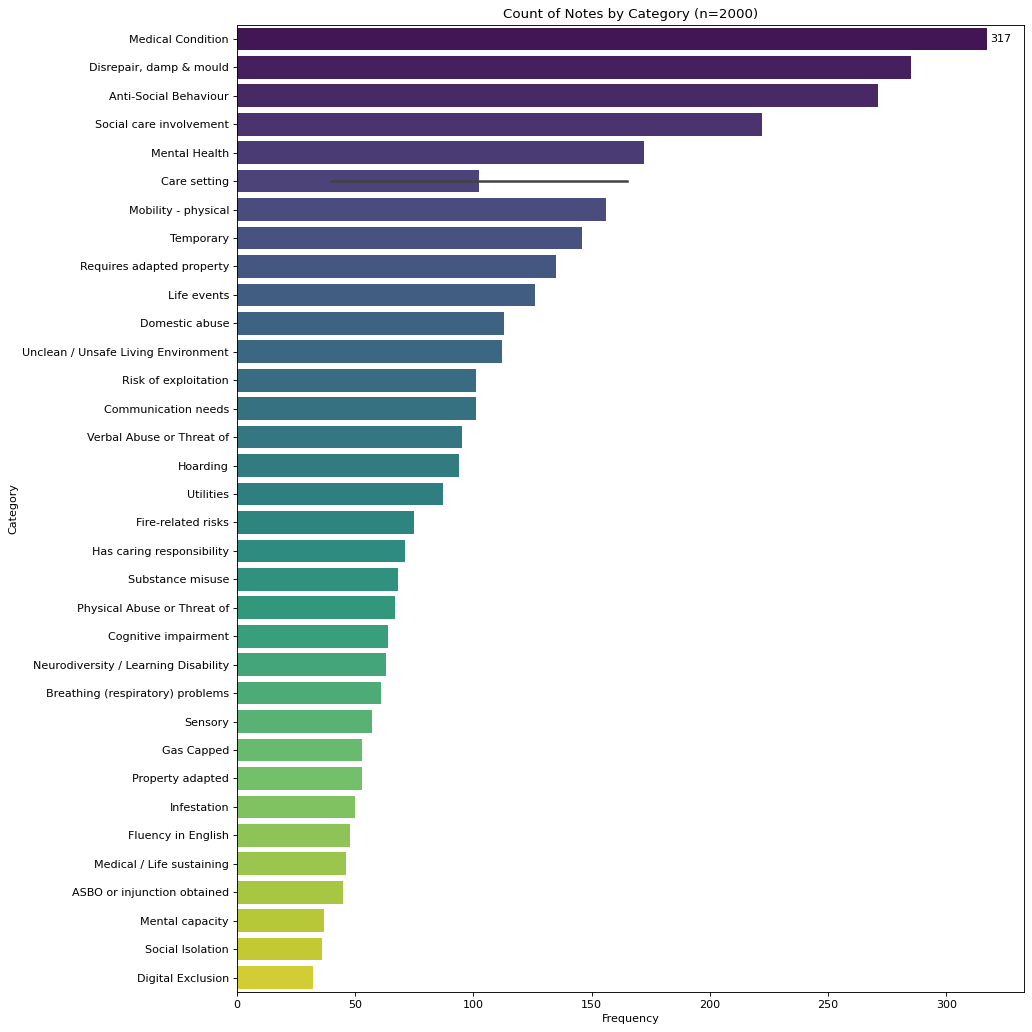

In [26]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records_v2, taxonomy_v3, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

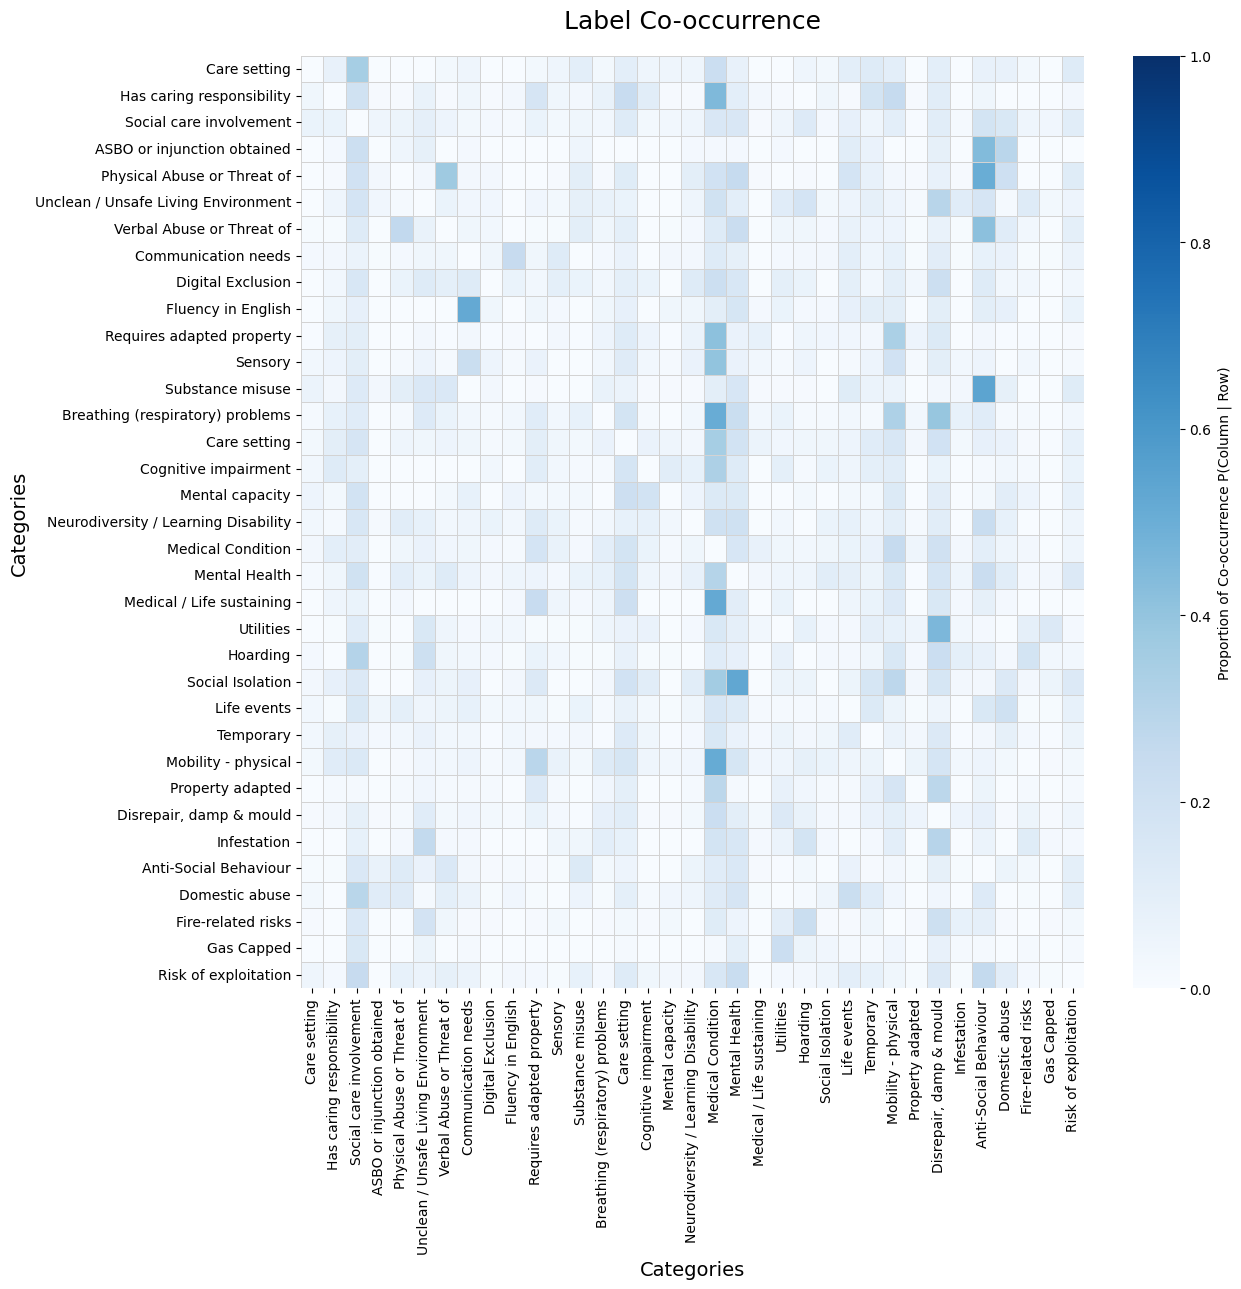

<Axes: title={'center': 'Label Co-occurrence'}, xlabel='Categories', ylabel='Categories'>

In [27]:
plot_cooccurrence_heatmap(records_v2, taxonomy_v3)

## Save as JSON

In [28]:
# Dump all
with open(FULL_DATA_OUTPUT_PATH, "w") as f:
    json.dump(records, f, indent=2)
